In [13]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
# 2. Load Dataset
df = pd.read_csv("C:/Users/Acer/Downloads/q1_heart_disease.csv")

In [15]:
# Display shape of dataset
print("Shape of dataset (rows, columns):", df.shape)

# Display data types of each column
print("\nData Types:\n", df.dtypes)

# Display missing values count
print("\nMissing Values:\n", df.isnull().sum())

# Show first 5 rows
print("\nFirst 5 rows of dataset:")
df.head()

Shape of dataset (rows, columns): (800, 12)

Data Types:
 age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Values:
 age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 rows of dataset:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


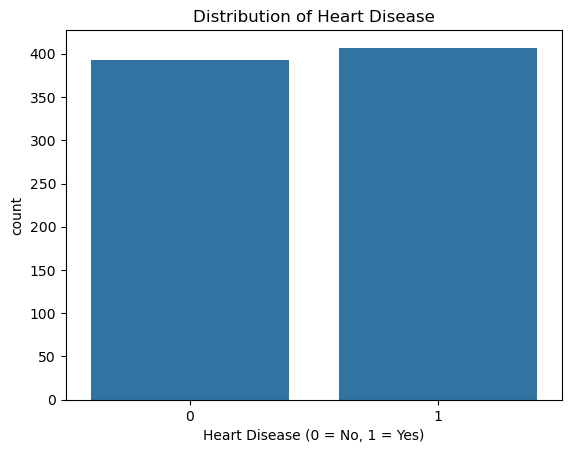

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(x='heart_disease', data=df)
plt.title('Distribution of Heart Disease')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.show()

The distribution of the target variable shows how many individuals have heart disease (1) versus those who do not (0). This helps determine whether the dataset is balanced or imbalanced. A balanced dataset ensures that models do not become biased toward one class.

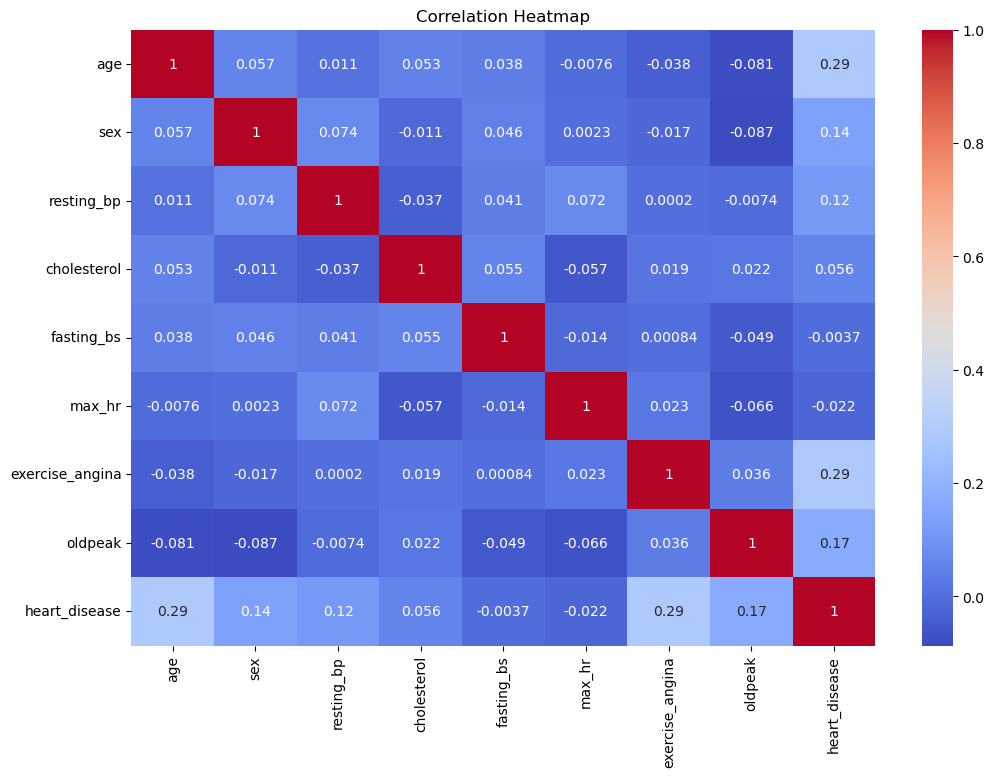

In [17]:
plt.figure(figsize=(12,8))
sns.heatmap(df.select_dtypes(include=['int64', 'float64']).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

The heatmap highlights relationships between numerical variables. Features showing strong correlation with the target variable are likely important predictors. Weak correlations suggest less influence on heart disease prediction.

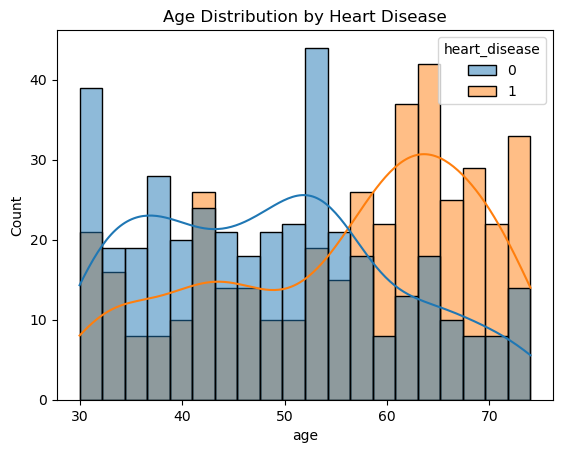

In [18]:
sns.histplot(data=df, x='age', hue='heart_disease', bins=20, kde=True)
plt.title('Age Distribution by Heart Disease')
plt.show()

The distribution shows how heart disease varies across age groups. If older individuals show a higher frequency of heart disease, age can be considered a significant factor in prediction.

In [19]:
# Check missing values
print(df.isnull().sum())

# Numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill missing values
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


C:\Users\Acer\AppData\Local\Temp\ipykernel_6988\3589267555.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


Missing values in numerical columns were filled using the median to reduce the impact of outliers. Categorical variables were filled using the mode, preserving the most frequent category.

In [20]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

Categorical variables were converted into numerical form using one-hot encoding. Only categorical columns were encoded to avoid unnecessary transformation of numerical features.

In [21]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('heart_disease', axis=1)
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

The dataset was split into training and testing sets using an 80-20 ratio with stratified sampling to maintain class balance.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature scaling was applied using StandardScaler after splitting to prevent data leakage and ensure fair model training.

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


Three classification models were trained: Decision Tree, Random Forest, and Gradient Boosting.
A fixed random state was used to ensure reproducibility of results.
These models were selected because they are widely used for classification tasks and can capture different patterns in the data.

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

# Predictions
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_gb = gb_model.predict(X_test_scaled)

# Function to print results
def evaluate_model(name, y_test, y_pred):
    print(f"----- {name} -----")
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("\n")

# Evaluate all models
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)

----- Decision Tree -----

Confusion Matrix:
[[57 22]
 [25 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.72      0.71        79
           1       0.72      0.69      0.70        81

    accuracy                           0.71       160
   macro avg       0.71      0.71      0.71       160
weighted avg       0.71      0.71      0.71       160



----- Random Forest -----

Confusion Matrix:
[[61 18]
 [15 66]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.77      0.79        79
           1       0.79      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160



----- Gradient Boosting -----

Confusion Matrix:
[[61 18]
 [19 62]]

Classification Report:
              precision    recall  f1-score   support

           0       

The Decision Tree model achieves an F1-score of around 0.70 for both classes, indicating moderate performance. However, it shows relatively higher misclassifications in the confusion matrix, suggesting that it may be overfitting and not generalizing well to unseen data.

The Random Forest model performs significantly better, with an F1-score of approximately 0.79–0.80 for both classes. It also shows fewer misclassifications in the confusion matrix, indicating improved predictive performance and better generalization due to the ensemble approach.

The Gradient Boosting model also performs well, with an F1-score of around 0.77. While it performs better than the Decision Tree, it is slightly less effective than the Random Forest in terms of both precision and recall.

Among all the models, the Random Forest Classifier performs the best. This is supported by its highest F1-score (~0.80), along with a strong balance between precision and recall for both classes.
Additionally, the confusion matrix shows fewer false positives and false negatives compared to the other models, indicating more reliable predictions.
F1-score is considered here instead of accuracy because it provides a better measure of model performance by balancing both precision and recall, especially in classification problems.

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

# Initialize model
rf = RandomForestClassifier(random_state=42)

# Grid Search
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Train
grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


Hyperparameter tuning was performed on the Random Forest model using GridSearchCV. Multiple combinations of parameters such as number of estimators, maximum depth, and minimum samples split were tested using 5-fold cross-validation. The F1-score was used as the evaluation metric to ensure a balance between precision and recall.

In [26]:
# Best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred_tuned = best_rf.predict(X_test_scaled)

from sklearn.metrics import classification_report, confusion_matrix

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_tuned))
print("\nClassification Report:\n", classification_report(y_test, y_pred_tuned))

Confusion Matrix:
 [[57 22]
 [15 66]]

Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.72      0.75        79
           1       0.75      0.81      0.78        81

    accuracy                           0.77       160
   macro avg       0.77      0.77      0.77       160
weighted avg       0.77      0.77      0.77       160



The tuned Random Forest model achieved an F1-score of approximately 0.77, which is slightly lower than the baseline Random Forest model (≈0.80).
The confusion matrix also indicates a slight increase in misclassifications compared to the untuned model.Although hyperparameter tuning is generally expected to improve model performance, in this case, the tuned model did not outperform the baseline Random Forest. This may be due to the dataset already being well-suited to the default parameters or the limited parameter grid explored.
Therefore, the original Random Forest model remains the best-performing model for this dataset.: